# BioPlex Compartment Organization Project — Stages 0 & 1

**Goal of this notebook:** build the two foundational objects the rest of the project depends on:

1. **Stage 0 — Data acquisition:** download the BioPlex 3.0 HEK293T and HCT116 interaction networks, and apply a confidence filter based on the CompPASS `pInt` score.
2. **Stage 1 — Compartment labeling:** attach a subcellular-compartment label to every protein in the network, using the COMPARTMENTS database (Jensen lab), and split proteins into a **single-compartment set** (for the mixing-matrix analysis in Stage 2) and a **multi-compartment set** (held out as a validation set for the mediator-protein analysis in Stage 3).

**Note:** this notebook needs internet access (to hit `bioplex.hms.harvard.edu`, `download.jensenlab.org`, and possibly the UniProt ID-mapping endpoint).

**Outputs of this notebook** (saved to `./data/stage0_1`):
- `bioplex_hek293t_edges.csv`, `bioplex_hct116_edges.csv` — filtered interaction edge lists
- `protein_compartments.csv` — protein → compartment label(s) + confidence, with a `n_compartments` column marking single- vs. multi-localizing proteins

These feed directly into Stage 2 (mixing matrix) next.

## Stage 0: Data Acquisition

### 0.1 Setup

Try the `bioplexpy` package first (it wraps the BioPlex download + column-mapping logic for us: https://github.com/ccb-hms/BioPlexPy). If it's unavailable or its API has drifted, we fall back to pulling the CSVs directly from the BioPlex download page.

In [23]:
# Core dependencies. bioplexpy is optional (we fall back to direct download if it's missing
# or its API doesn't match what we expect).
%pip install -q pandas numpy scipy networkx matplotlib requests
%pip install -q bioplexpy


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85428) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85428) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [24]:
import io
import pandas as pd
import numpy as np
import networkx as nx
import requests
from pathlib import Path

DATA_DIR = Path("data/stage0_1")
DATA_DIR.mkdir(exist_ok=True)

# jensenlab.org (COMPARTMENTS) rejects requests with the default Python/urllib User-Agent
# with a 403 -- send a browser-like one on every request to that host.
HTTP_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; bioplex-notebook/1.0)"}

pd.set_option("display.max_columns", 20)


### 0.2 Download the BioPlex networks

BioPlex 3.0 ships two cell-line-specific networks (Huttlin et al. 2021, *Cell*):

| Network | Cell line | Baits | Interactions |
|---|---|---|---|
| BioPlex 3.0 (293T) | HEK293T | 10,128 | ~120,000 |
| BioPlex 3.0 (HCT116) | HCT116 | 5,522 | ~71,000 |

Each interaction row includes three CompPASS-derived confidence scores:
- `pW` — probability the identification is wrong
- `pNI` — probability it's background / non-interactor
- `pInt` — probability it's a real interaction (**this is the one we filter on**)

Try `bioplexpy.getBioPlex()` first; if that fails for any reason, we fall back to the direct
CSV download from the BioPlex site.

In [ ]:
def get_bioplex_network(cell_line: str, version: str = "3.0") -> pd.DataFrame:
    """Fetch a BioPlex interaction table for a given cell line and version.

    Tries bioplexpy first, falls back to a direct CSV download.

    Parameters:
        cell_line (str): the BioPlex cell line to fetch (e.g. "293T" or "HCT116").
        version (str): the BioPlex network version to fetch. Defaults to "3.0".

    Returns:
        (pd.DataFrame): raw interaction table with (at minimum) UniprotA, UniprotB,
            SymbolA, SymbolB, pW, pNI, and pInt columns.

    Raises:
        ValueError: if bioplexpy fails and no fallback download URL is registered for the
            given (cell_line, version) pair.
    """
    # --- Attempt 1: bioplexpy ---
    try:
        from bioplexpy import getBioPlex
        df = getBioPlex(cell_line=cell_line, version=version)
        print(f"[bioplexpy] Retrieved {len(df):,} interactions for {cell_line}")
        return df
    except Exception as e:
        print(f"[bioplexpy] failed ({e!r}); falling back to direct download.")

    # --- Attempt 2: direct download from bioplex.hms.harvard.edu ---
    # NOTE: verify these URLs still resolve -- the BioPlex download page
    # (https://bioplex.hms.harvard.edu/interactions.php) occasionally changes its file paths.
    direct_urls = {
        ("293T", "3.0"): "https://bioplex.hms.harvard.edu/data/BioPlex_293T_Network_10K_Dec_2019.tsv",
        ("HCT116", "3.0"): "https://bioplex.hms.harvard.edu/data/BioPlex_HCT116_Network_5.5K_Dec_2019.tsv",
    }
    key = (cell_line, version)
    if key not in direct_urls:
        raise ValueError(f"No fallback URL registered for {key}. Check the BioPlex download page manually.")

    url = direct_urls[key]
    print(f"[direct] Downloading {url}")
    df = pd.read_csv(url, sep="\t")
    print(f"[direct] Retrieved {len(df):,} rows. Columns: {list(df.columns)}")
    return df

# Raw data frames.
bp_293t_raw = get_bioplex_network("293T")
bp_hct116_raw = get_bioplex_network("HCT116")

bp_293t_raw.head()

In [26]:
rename_map = {
    "GeneA": "GeneIdA", "GeneB": "GeneIdB",
    "SymbolA": "SymbolA", "SymbolB": "SymbolB",
    "UniprotA": "UniprotA", "UniprotB": "UniprotB",
    "pW": "pW", "pNI": "pNI", "pInt": "pInt",
}

bp_293t = bp_293t_raw.rename(columns=rename_map)
bp_hct116 = bp_hct116_raw.rename(columns=rename_map)

print(f"293T: {len(bp_293t):,} raw interactions")
print(f"HCT116: {len(bp_hct116):,} raw interactions")

bp_293t.head()

293T: 118,162 raw interactions
HCT116: 70,966 raw interactions


,GeneIdA,GeneIdB,UniprotA,UniprotB,SymbolA,SymbolB,pW,pNI,pInt
0,100,728378,P00813,A5A3E0,ADA,POTEF,6.881844e-10,0.000118,0.999882
1,222389,6137,Q8N7W2-2,P26373,BEND7,RPL13,1.340380e-18,0.225664,0.774336
2,222389,5928,Q8N7W2-2,Q09028-3,BEND7,RBBP4,7.221401e-21,0.000064,0.999936
3,222389,25873,Q8N7W2-2,Q9Y3U8,BEND7,RPL36,7.058372e-17,0.128183,0.871817
4,222389,6124,Q8N7W2-2,P36578,BEND7,RPL4,1.632313e-22,0.200638,0.799362


### 0.3 Confidence filtering

We filter on `pInt` (probability of being a true interaction, per CompPASS). We'll use **two
thresholds** throughout the project, not just one:

- `PINT_MAIN = 0.75` — our primary working threshold (matches conventions used in BioPlex's own papers)
- `PINT_STRICT = 0.9` — a stricter cut, used later as a robustness check in Stage 5

We keep both filtered versions on disk now so we don't have to re-download later.

In [ ]:
PINT_MAIN = 0.75
PINT_STRICT = 0.90

def filter_by_confidence(df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """Filter a BioPlex interaction table down to a minimum pInt confidence score, and print
    how many interactions were retained.

    Parameters:
        df (pd.DataFrame): interaction table containing a `pInt` column.
        threshold (float): minimum pInt score (CompPASS probability of a true interaction)
            an interaction must meet to be retained.

    Returns:
        (pd.DataFrame): copy of `df` containing only rows with `pInt >= threshold`.
    """
    filtered = df[df["pInt"] >= threshold].copy()
    print(f"  pInt >= {threshold}: {len(filtered):,} / {len(df):,} interactions retained "
          f"({len(filtered) / len(df):.1%})")
    return filtered

print("293T:")
bp_293t_main = filter_by_confidence(bp_293t, PINT_MAIN)
bp_293t_strict = filter_by_confidence(bp_293t, PINT_STRICT)

print("HCT116:")
bp_hct116_main = filter_by_confidence(bp_hct116, PINT_MAIN)
bp_hct116_strict = filter_by_confidence(bp_hct116, PINT_STRICT)

### 0.4 Build undirected simple graphs (sanity check)

AP-MS interactions are bait→prey (directed) by construction, but for this project we treat
"A pulled down B" and "B pulled down A" as the same underlying physical association and collapse
to an **undirected simple graph** (this is standard practice in BioPlex's own network analyses).
We keep the max `pInt` when both directions were observed.

In [ ]:
def build_graph(df: pd.DataFrame) -> nx.Graph:
    """Collapse a directed BioPlex interaction table into an undirected simple graph, keeping
    the max pInt when both directions (A->B and B->A) were observed for a pair, and dropping
    self-interactions.

    Parameters:
        df (pd.DataFrame): interaction table with UniprotA, UniprotB, and pInt columns.

    Returns:
        (nx.Graph): undirected graph with one edge per distinct protein pair, each edge
            carrying a `pInt` attribute (the max of the two directions' scores, if both were
            observed).
    """
    G = nx.Graph()
    for _, row in df.iterrows():
        u, v, p = row["UniprotA"], row["UniprotB"], row["pInt"]
        if u == v:
            continue  # drop self-interactions
        if G.has_edge(u, v):
            G[u][v]["pInt"] = max(G[u][v]["pInt"], p)
        else:
            G.add_edge(u, v, pInt=p)
    return G

# Sanity check: These graphs are not used in this file!
G_293t = build_graph(bp_293t_main)
G_hct116 = build_graph(bp_hct116_main)

print(f"293T graph:   {G_293t.number_of_nodes():,} nodes, {G_293t.number_of_edges():,} edges")
print(f"HCT116 graph: {G_hct116.number_of_nodes():,} nodes, {G_hct116.number_of_edges():,} edges")

In [30]:
# Persist the filtered edge lists (Stage 2 will re-load these rather than re-downloading).
bp_293t_main[["UniprotA", "UniprotB", "SymbolA", "SymbolB", "pInt"]].to_csv(
    DATA_DIR / "bioplex_hek293t_edges.csv", index=False
)
bp_hct116_main[["UniprotA", "UniprotB", "SymbolA", "SymbolB", "pInt"]].to_csv(
    DATA_DIR / "bioplex_hct116_edges.csv", index=False
)
print("Saved filtered edge lists to ./data/stage0_1")


Saved filtered edge lists to ./data/stage0_1


## Stage 1: Compartment Labeling

### 1.1 Download the COMPARTMENTS knowledge channel

We use the **knowledge channel** specifically (manually curated evidence only — UniProt keywords,
GO annotations from curated databases, etc.), rather than the "integrated" file, which also
folds in text-mining and sequence-based predictions. The knowledge channel is smaller and noisier
in coverage but much more trustworthy label-for-label, which matters more than coverage for a
first pass.

Source: https://compartments.jensenlab.org/Downloads
File: `human_compartment_knowledge_full.tsv`

Based on the COMPARTMENTS documentation, the columns are, in order:

`gene_id | gene_symbol | go_id | go_name | source | eivdence_code | confidence_score (1-5 stars)`

In [8]:
COMPARTMENTS_URL = "https://download.jensenlab.org/human_compartment_knowledge_full.tsv"

# Expected schema per COMPARTMENTS documentation -- CONFIRM against the printout below
KNOWLEDGE_COLS = ["gene_id", "gene_symbol", "go_id", "go_term", "source", "evidence_code", "confidence_score"]

# pd.read_csv(url) hits the URL via urllib, whose default User-Agent gets a 403 from
# jensenlab.org -- fetch with requests (like the sample above) and parse the text instead.
compartments_resp = requests.get(COMPARTMENTS_URL, headers=HTTP_HEADERS)
compartments_resp.raise_for_status()
compartments_raw = pd.read_csv(
    io.StringIO(compartments_resp.text), sep="\t", header=None, names=KNOWLEDGE_COLS
)
print(f"Loaded {len(compartments_raw):,} localization evidence rows for {compartments_raw['gene_symbol'].nunique():,} genes")
compartments_raw.sample(10)


Loaded 910,242 localization evidence rows for 18,520 genes


,gene_id,gene_symbol,go_id,go_term,source,evidence_code,confidence_score
20521,ENSP00000216487,RIN3,GO:0005737,Cytoplasm,ARUK-UCL,IDA,4
725255,ENSP00000415049,GSDMB,GO:0005829,Cytosol,HPA,IDA,4
720963,ENSP00000412886,CAMTA2,GO:0005634,Nucleus,HPA,IDA,4
788510,ENSP00000445043,FRY,GO:0005815,Microtubule organizing center,UniProtKB-SubCell,IEA,3
145134,ENSP00000264279,NOP58,GO:0070013,Intracellular organelle lumen,BHF-UCL,IDA,4
784463,ENSP00000442308,NKRF,GO:0043227,membrane-bounded organelle,HPA,IDA,4
714673,ENSP00000409738,TMBIM1,GO:0016020,Membrane,UniProtKB-KW,IEA,3
422013,ENSP00000348496,SUN5,GO:0034992,Microtubule organizing center attachment site,GO_Central,IBA,3
13978,ENSP00000211122,GSTA3,GO:0005622,Intracellular anatomical structure,HPA,IDA,4
785160,ENSP00000442600,DAG1,GO:0098684,Photoreceptor ribbon synapse,Ensembl,IEA,2


### 1.2 Collapse fine-grained GO terms into coarse compartment categories

COMPARTMENTS evidence is mapped to specific GO Cellular Component terms — there are far more of
these than we want as categories for a mixing matrix (e.g. "mitochondrial matrix", "mitochondrial
inner membrane", and "mitochondrial outer membrane" are all separate GO terms, but for our
purposes they're all "mitochondrion"). We define a coarse mapping to ~15 top-level compartments.

**This mapping is a judgment call and worth revisiting later** — how coarse or fine you go
changes the resolution of the mixing matrix. Start coarse, and consider a finer-grained rerun
(e.g. splitting mitochondrial subcompartments) once the main analysis is working, since some of
the most interesting biology (e.g. ER-mitochondria contact sites) lives at exactly that finer
level.

In [ ]:
import re

# Specific compartments used for intra-/inter-compartment classification.
# Order matters: more specific / potentially overlapping terms must come first,
# since match_rule stops at the first hit.
SPECIFIC_COMPARTMENT_RULES = [
    ("nucleolus", ["nucleolus"]),

    ("er_golgi_intermediate", [
        "ergic",
        "er-golgi intermediate",
        "endoplasmic reticulum-golgi intermediate",
    ]),

    ("synapse", ["synapse", "synaptic"]),

    # Mitochondrion before nucleus so "mitochondrial chromosome" doesn't
    # get caught by the nucleus rule's "chromosome" keyword.
    ("mitochondrion", ["mitochondri"]),

    ("nucleus", [
        "nucleus",
        "nuclear",
        "nucleoplasm",
        "chromatin",
        "chromosome",
    ]),

    ("endoplasmic_reticulum", ["endoplasmic reticulum"]),
    ("golgi", ["golgi"]),
    ("lysosome", ["lysosom"]),
    ("peroxisome", ["peroxisom"]),
    ("endosome", ["endosom"]),
    ("cell junction", ["cell junction"]),
    ("plasma_membrane", ["plasma membrane", "cell surface"]),
    ("extracellular", ["extracellular", "secreted"]),
    ("cytoskeleton", ["cytoskeleton", "microtubule", "actin filament"]),

    # Vesicle before any broader cytoplasmic matching.
    ("vesicle", ["vesicle"]),

    # Cytoplasm is broader than cytosol -- deliberately excluded here.
    ("cytosol", ["cytosol"]),
]

# Useful localization evidence, but too broad/ambiguous to call a specific organelle.
BROAD_COMPARTMENT_RULES = [
    ("cell_periphery", ["cell periphery"]),
    ("endomembrane_system", ["endomembrane system"]),
    ("cytoplasm_unspecified", ["cytoplasm"]),
]


def keyword_matches(term_lower: str, keyword: str) -> bool:
    """Check whether `keyword` appears in `term_lower` at a word boundary, anchored on the
    left only.

    This blocks partial-word false positives on the left (e.g. "perinuclear" does not match
    the keyword "nuclear"), but not on the right, so a keyword stem like "mitochondri" still
    matches "mitochondrial", "mitochondria", and "mitochondrion".

    Parameters:
        term_lower (str): lower-cased GO term text to search within.
        keyword (str): keyword (or keyword stem) to search for.

    Returns:
        (bool): True if `keyword` matches `term_lower` at a left word boundary, False
            otherwise.
    """
    return re.search(r"\b" + re.escape(keyword), term_lower) is not None


def match_rule(go_term: str, rules) -> str | None:
    """Find the first compartment whose keyword list matches a GO term, per an ordered list
    of (compartment, keywords) rules.

    Parameters:
        go_term (str): the raw GO Cellular Component term text to classify.
        rules (list[tuple[str, list[str]]]): ordered list of (compartment_name, keywords)
            pairs to test against. Order matters -- more specific or potentially overlapping
            terms must come first, since this returns on the first hit.

    Returns:
        (str | None): the name of the first matching compartment, or None if no rule
            matches.
    """
    term_lower = go_term.lower()
    for compartment, keywords in rules:
        if any(keyword_matches(term_lower, kw) for kw in keywords):
            return compartment
    return None


def map_go_term(go_term: str) -> tuple[str | None, str]:
    """Classify a GO Cellular Component term into a coarse compartment label, checking the
    specific-compartment rules first and falling back to the broad-compartment rules.

    Parameters:
        go_term (str): the raw GO Cellular Component term text to classify.

    Returns:
        (tuple[str | None, str]): a (compartment, resolution) pair, where `compartment` is
            the matched compartment name (or None if unmapped) and `resolution` is one of
            "specific", "broad", or "unmapped", describing which rule set (if any) matched.
    """
    specific = match_rule(go_term, SPECIFIC_COMPARTMENT_RULES)
    if specific is not None:
        return specific, "specific"

    broad = match_rule(go_term, BROAD_COMPARTMENT_RULES)
    if broad is not None:
        return broad, "broad"

    return None, "unmapped"

mapped_results = compartments_raw["go_term"].apply(map_go_term)
compartments_raw[["coarse_compartment", "mapping_resolution"]] = pd.DataFrame(
    mapped_results.tolist(), index=compartments_raw.index
)

n_total = len(compartments_raw)
res_counts = compartments_raw["mapping_resolution"].value_counts()
print("Mapping resolution breakdown:")
for res in ["specific", "broad", "unmapped"]:
    n = res_counts.get(res, 0)
    print(f"  {res:10s}: {n:,} ({n/n_total:.1%})")

print("\nTop 20 fully unmapped GO terms (by frequency) -- check if any deserve a rule above:")
print(
    compartments_raw.loc[compartments_raw["mapping_resolution"].eq("unmapped"), "go_term"]
    .value_counts()
    .head(20)
)

Look at the "unmapped GO terms" list above and add
rules for any high-frequency terms that clearly belong to a real compartment (e.g. "nuclear
envelope" should probably join `nucleus`). Terms that are genuinely ambiguous or process-based
rather than location-based (e.g. "protein binding") can stay unmapped — those rows just get
dropped in the next step.

### 1.3 Resolve one compartment call per gene, with confidence filtering

For each gene, we may have multiple evidence rows (different GO terms, different sources). We:

1. Keep only **specific**-resolution rows (drop unmapped rows, and drop broad-tier rows like
   "endomembrane system" or "cytoplasm, unspecified" -- those are real evidence but don't
   discriminate between organelles).
2. Keep only evidence at confidence >= `MIN_CONFIDENCE` (COMPARTMENTS knowledge-channel scores
   run 1-5 stars; we use 3+ as "reasonably trustworthy manually curated evidence").
3. Collapse to the **set of distinct coarse compartments** per gene.
4. Record `n_compartments` — this is what splits proteins into the single- vs. multi-localizing
   sets we'll use in Stages 2 and 3.

In [10]:
MIN_CONFIDENCE = 3  # out of 5 stars, per COMPARTMENTS scoring

# Only "specific" resolution rows count toward a compartment call. "broad" rows
# (endomembrane system, cytoplasm_unspecified, cell_periphery) are real evidence
# a protein isn't, e.g., extracellular -- but not evidence for which specific
# organelle it's in, so they must not leak into the mixing-matrix analysis.
specific_localizations = compartments_raw.loc[
    compartments_raw["mapping_resolution"].eq("specific")
].copy()

mapped = specific_localizations[specific_localizations["confidence_score"] >= MIN_CONFIDENCE]

gene_compartments = (
    mapped.groupby("gene_symbol")["coarse_compartment"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
    .rename(columns={"coarse_compartment": "compartments", "gene_symbol": "symbol"})
)
gene_compartments["n_compartments"] = gene_compartments["compartments"].apply(len)

print(f"{len(gene_compartments):,} genes have at least one confident, specific compartment call.")
print("\nDistribution of number of distinct compartments per gene:")
print(gene_compartments["n_compartments"].value_counts().sort_index())

gene_compartments.head()


17,527 genes have at least one confident, specific compartment call.

Distribution of number of distinct compartments per gene:
n_compartments
1     7005
2     4247
3     2779
4     1531
5      931
6      516
7      293
8      130
9       63
10      21
11       5
12       5
13       1
Name: count, dtype: int64


,symbol,compartments,n_compartments
0,A1BG,"[extracellular, plasma_membrane, vesicle]",3
1,A1CF,"[endoplasmic_reticulum, nucleus]",2
2,A2M,"[extracellular, vesicle]",2
3,A2ML1,"[extracellular, vesicle]",2
4,A3GALT2,"[golgi, vesicle]",2


### 1.4 Join compartment labels onto the BioPlex proteins

BioPlex identifies proteins by UniProt accession; COMPARTMENTS (knowledge channel) identifies
them by gene symbol. We join on gene symbol for now — it's simpler than an ID-mapping round trip
and both datasets carry it natively, but **gene symbols are not a perfectly stable key** (synonyms,
outdated names, one-to-many mappings for isoforms). We flag this as a known limitation to revisit:
if coverage looks poor or joins look wrong, the fix is a proper UniProt-to-UniProt mapping via the
UniProt ID Mapping REST API (https://rest.uniprot.org/idmapping) instead of symbol matching.

In [11]:
# All distinct proteins seen in either BioPlex network, with their gene symbols
proteins_293t = pd.concat([
    bp_293t_main[["UniprotA", "SymbolA"]].rename(columns={"UniprotA": "uniprot", "SymbolA": "symbol"}),
    bp_293t_main[["UniprotB", "SymbolB"]].rename(columns={"UniprotB": "uniprot", "SymbolB": "symbol"})
])

proteins_hct116 = pd.concat([
    bp_hct116_main[["UniprotA", "SymbolA"]].rename(columns={"UniprotA": "uniprot", "SymbolA": "symbol"}),
    bp_hct116_main[["UniprotB", "SymbolB"]].rename(columns={"UniprotB": "uniprot", "SymbolB": "symbol"})
])

all_proteins = pd.concat([proteins_293t, proteins_hct116]).drop_duplicates(subset=["uniprot"])
print(f"{len(all_proteins):,} distinct proteins across both BioPlex networks.")

protein_compartments = all_proteins.merge(gene_compartments, on="symbol", how="left")

n_labeled = protein_compartments["compartments"].notna().sum()
print(f"{n_labeled:,} / {len(protein_compartments):,} proteins "
      f"({n_labeled/len(protein_compartments):.1%}) received at least one compartment label.")

proteins_293t.sample(5)


15,400 distinct proteins across both BioPlex networks.
13,011 / 15,400 proteins (84.5%) received at least one compartment label.


,uniprot,symbol
79213,Q8WYR4,RSPH1
89994,Q9HC56-2,PCDH9
50953,Q3MIR4,TMEM30B
85289,Q8TEB1-2,DCAF11
51582,P60709,ACTB


In [12]:
# Split into single- vs. multi-compartment sets.
labeled = protein_compartments.dropna(subset=["compartments"]).copy()
labeled["n_compartments"] = labeled["compartments"].apply(len)

single_compartment = labeled[labeled["n_compartments"] == 1].copy()
single_compartment["compartment"] = single_compartment["compartments"].apply(lambda x: x[0])

multi_compartment = labeled[labeled["n_compartments"] > 1].copy()

print(f"Single-compartment proteins (-> Stage 2 mixing matrix): {len(single_compartment):,}")
print(f"Multi-compartment proteins (-> Stage 3 validation set): {len(multi_compartment):,}")

print("\nCompartment counts among single-compartment proteins:")
print(single_compartment["compartment"].value_counts())


Single-compartment proteins (-> Stage 2 mixing matrix): 4,515
Multi-compartment proteins (-> Stage 3 validation set): 8,496

Compartment counts among single-compartment proteins:
compartment
nucleus                  2034
plasma_membrane           804
mitochondrion             519
cytosol                   423
extracellular             374
golgi                     132
cytoskeleton              112
endoplasmic_reticulum      53
vesicle                    25
lysosome                   18
cell junction              13
peroxisome                  8
Name: count, dtype: int64


### 1.5 Quick QC visualization

Before moving to Stage 2, sanity-check that the compartment distribution looks biologically
reasonable (e.g. nucleus and cytosol should dominate by raw protein count; small organelles like
peroxisomes should be rare but present).

Matplotlib is building the font cache; this may take a moment.


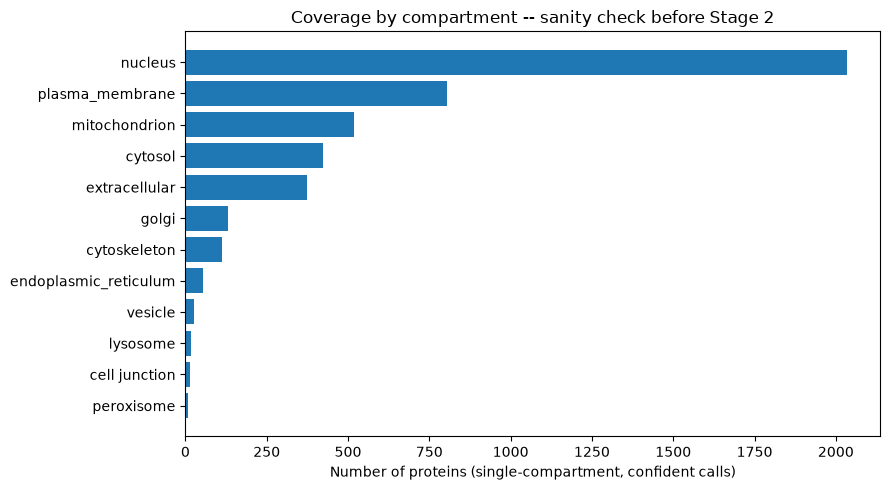

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
counts = single_compartment["compartment"].value_counts().sort_values()
ax.barh(counts.index, counts.values)
ax.set_xlabel("Number of proteins (single-compartment, confident calls)")
ax.set_title("Coverage by compartment -- sanity check before Stage 2")
plt.tight_layout()
plt.savefig(DATA_DIR / "compartment_coverage_qc.png", dpi=150)
plt.show()


### 1.6 Save Stage 1 outputs

We save one table with everything Stage 2 and Stage 3 need: every protein, its compartment
set, its single/multi status, and the coarse compartment (where applicable).

In [ ]:
protein_compartments_out = labeled[["uniprot", "symbol", "compartments", "n_compartments"]].copy()
protein_compartments_out["compartments"] = protein_compartments_out["compartments"].apply(
    lambda x: ";".join(x)  # flatten list to a delimited string for CSV storage
)

protein_compartments_out.to_csv(DATA_DIR / "protein_compartments.csv", index=False)
print(f"Saved {len(protein_compartments_out):,} labeled proteins to ./data/stage0_1/protein_compartments.csv")

protein_compartments_out.head()

## Recap and what's next

At this point `./data/stage0_1` contains:
- `bioplex_hek293t_edges.csv`, `bioplex_hct116_edges.csv` — confidence-filtered (pInt >= 0.75) edge lists
- `protein_compartments.csv` — every labeled protein, its compartment set, and single/multi status
- `compartment_coverage_qc.png` — sanity-check plot

**Two things worth checking by hand before Stage 2:**
1. The unmapped-GO-term list in 1.2 — did we miss any obviously real compartments?
2. Overall coverage in 1.4 — what fraction of BioPlex proteins ended up with *no* compartment
   label at all? If that number is large, the symbol-matching join is probably losing proteins we
   could recover with a proper UniProt ID-mapping step.

**Stage 2, next:** build the compartment x compartment mixing matrix on `single_compartment`,
with a degree-preserving randomization as the null model, and produce the first enrichment/depletion
heatmap for the HEK293T network.